# Day 02：退化问题的代码实证 —— 用数据说话> 🌉 第七周 · ResNet 的奇迹 · 第 2 天昨天我们认识了退化问题——网络越深反而越蠢。但"认识"和"理解"之间，隔着一道鸿沟。今天，我们要亲手用代码**制造**退化，**测量**退化，**可视化**退化。只有亲眼看到数据，你才会真正相信：这不是理论猜测，而是铁一般的事实。**今天的任务**：1. 系统地对比不同深度网络的训练表现2. 用曲线图直观展示"退化曲线"3. 深入理解退化发生的根本原因---

## 1. 历史剧场：何恺明的"对照实验"2015 年，何恺明在论文中展示了一张震惊学术界的图：> 20 层网络和 56 层网络在 ImageNet 上的训练误差对比——56 层的训练误差始终高于 20 层。这张图之所以震撼，是因为它推翻了一个"常识"。在此之前，人们总是把深层网络表现差归咎于过拟合，然后用各种正则化手段去对付。但何恺明证明了：**问题出在训练本身**。今天，我们要复现这个实验的精神——用代码证明退化是真实存在的。---

## 2. 生活隐喻：接力赛中的"掉棒"想象一场 4×100 米接力赛：- **4 个人接力**：每个人跑 100 米，交接棒很顺利，总成绩不错- **20 个人接力**：每个人跑 20 米，但交接棒 19 次——每次交接都有风险掉棒- **100 个人接力**：每个人跑 1 米，交接棒 99 次——几乎不可能不掉棒深度网络就是一场"信息接力赛"：- 每一层接收上一层的输出，加工后传给下一层- 层数越多，"交接"次数越多- 每次交接都可能"掉棒"——信息丢失或扭曲- 最终结果：信息还没跑到终点，就已经面目全非了---

<p align="center">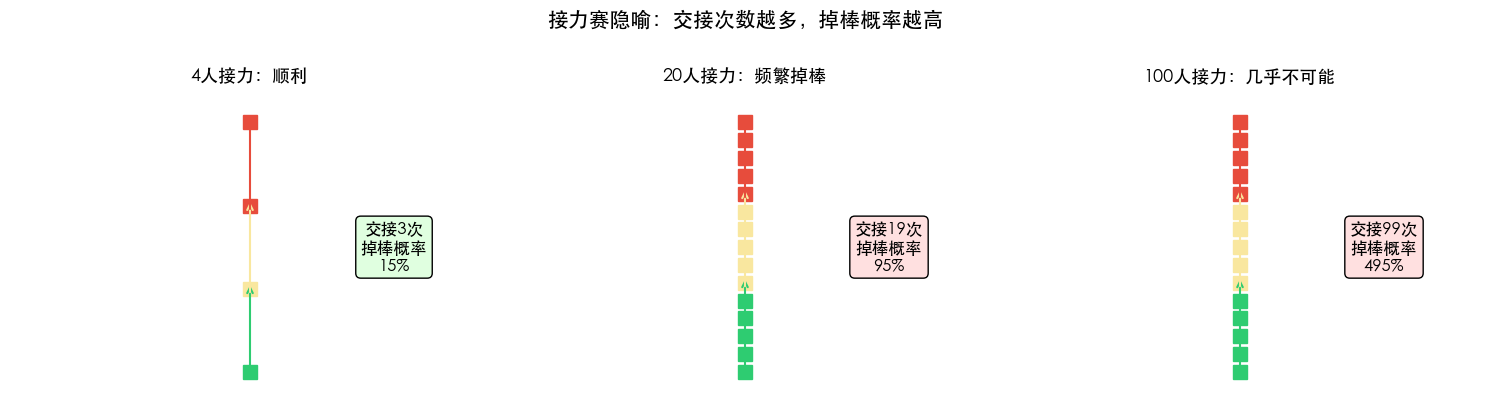</p>*接力赛掉棒示意图*

## 3. 代码实验室：系统性深度对比### 3.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.2 数据集：同心圆分类这次我们用一个稍难一点的数据——同心圆，它需要更复杂的决策边界。

In [ ]:
def make_circles_data(n_samples=500, noise=0.05):    """生成同心圆分类数据"""    np.random.seed(42)    n = n_samples // 2    theta_outer = np.random.uniform(0, 2 * np.pi, n)    theta_inner = np.random.uniform(0, 2 * np.pi, n)    r_outer = 1.0 + np.random.randn(n) * noise    r_inner = 0.5 + np.random.randn(n) * noise    x_outer = np.column_stack([r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)])    x_inner = np.column_stack([r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)])    X = np.vstack([x_outer, x_inner]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_circles, y_circles = make_circles_data()fig, ax = plt.subplots(1, 1, figsize=(6, 6))for label, color, marker in [(0, '#e74c3c', 'x'), (1, '#2ecc71', 'o')]:    mask = y_circles.squeeze() == label    ax.scatter(X_circles[mask, 0], X_circles[mask, 1],               c=color, marker=marker, s=25, alpha=0.6, label=f'类别 {int(label)}')ax.set_title('同心圆数据集', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)ax.set_aspect('equal')plt.tight_layout()plt.show()

### 3.3 定义可变深度的网络

In [ ]:
class PlainBlock(nn.Module):    """普通网络块：两层全连接 + BN + ReLU"""    def __init__(self, hidden_size):        super().__init__()        self.block = nn.Sequential(            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),            nn.ReLU(),            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),        )        self.relu = nn.ReLU()    def forward(self, x):        out = self.block(x)        out = self.relu(out)        return outclass VariableDepthNet(nn.Module):    """可变深度的普通网络"""    def __init__(self, input_size=2, hidden_size=64, num_blocks=4, output_size=1):        super().__init__()        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]        for _ in range(num_blocks):            layers.append(PlainBlock(hidden_size))        layers.append(nn.Linear(hidden_size, output_size))        layers.append(nn.Sigmoid())        self.net = nn.Sequential(*layers)    def forward(self, x):        return self.net(x)

### 3.4 系统性实验：从 1 层到 20 层

In [ ]:
depth_list = [1, 2, 4, 8, 12, 16, 20]all_losses = {}all_accuracies = {}epochs = 300for num_blocks in depth_list:    print(f"训练 {num_blocks} Block 网络...")    torch.manual_seed(42)    model = VariableDepthNet(num_blocks=num_blocks)    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)    loss_fn = nn.BCELoss()    losses = []    for epoch in range(epochs):        predicted_probability = model(X_circles)        loss = loss_fn(predicted_probability, y_circles)        optimizer.zero_grad()        loss.backward()        optimizer.step()        losses.append(loss.item())    final_acc = ((model(X_circles) > 0.5).float() == y_circles).float().mean().item()    all_losses[num_blocks] = losses    all_accuracies[num_blocks] = final_acc    print(f"  最终 Loss: {losses[-1]:.4f}, Acc: {final_acc:.4f}")print("\n实验完成！")

### 3.5 可视化：退化曲线

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(depth_list)))for i, num_blocks in enumerate(depth_list):    label = f'{num_blocks} Blocks'    axes[0].plot(all_losses[num_blocks], label=label, color=colors[i], alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Training Loss', fontsize=12)axes[0].set_title('不同深度的训练损失曲线', fontsize=14)axes[0].legend(fontsize=10)axes[0].grid(True, alpha=0.3)depths = list(all_accuracies.keys())accs = list(all_accuracies.values())axes[1].plot(depths, accs, 'o-', color='#e74c3c', linewidth=2, markersize=10)axes[1].set_xlabel('网络深度 (Block 数)', fontsize=12)axes[1].set_ylabel('训练准确率', fontsize=12)axes[1].set_title('退化曲线：越深越差', fontsize=14)axes[1].grid(True, alpha=0.3)for d, a in zip(depths, accs):    axes[1].annotate(f'{a:.2%}', (d, a), textcoords="offset points",                     xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')plt.tight_layout()plt.show()

### 解读左图：训练损失曲线。浅层网络（绿色）快速收敛到很低的损失，深层网络（红色）损失居高不下。右图：退化曲线。随着深度增加，训练准确率不升反降——这就是退化问题的铁证。---

## 4. 深层分析：退化到底发生在哪里？让我们更细致地观察：信息在网络中传递时，到底发生了什么？

In [ ]:
def track_signal_magnitude(model, X_sample):    """追踪信号在网络各层的幅度变化"""    activations = []    x = X_sample    for i, layer in enumerate(model.net):        x = layer(x) if not isinstance(layer, PlainBlock) else layer(x)        if i < len(model.net) - 1:            activations.append(x.detach().norm().item())    return activationstorch.manual_seed(42)shallow_model = VariableDepthNet(num_blocks=4)deep_model = VariableDepthNet(num_blocks=16)X_sample = X_circles[:10]shallow_acts = track_signal_magnitude(shallow_model, X_sample)deep_acts = track_signal_magnitude(deep_model, X_sample)fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].plot(range(len(shallow_acts)), shallow_acts, 'o-', color='#3498db', linewidth=2)axes[0].set_xlabel('层编号', fontsize=12)axes[0].set_ylabel('信号幅度 (L2 Norm)', fontsize=12)axes[0].set_title('浅层网络 (4 Blocks)：信号传递', fontsize=14)axes[0].grid(True, alpha=0.3)axes[1].plot(range(len(deep_acts)), deep_acts, 'o-', color='#e74c3c', linewidth=2)axes[1].set_xlabel('层编号', fontsize=12)axes[1].set_ylabel('信号幅度 (L2 Norm)', fontsize=12)axes[1].set_title('深层网络 (16 Blocks)：信号衰减', fontsize=14)axes[1].grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 解读- **浅层网络**：信号幅度在各层之间相对稳定- **深层网络**：信号幅度在传递过程中剧烈波动，甚至趋近于零当信号趋近于零时，梯度也趋近于零——网络就"学不动了"。这就是梯度消失的直观表现。---

## 5. 为什么 BatchNorm 没有彻底解决问题？你可能会问：我们不是已经在每一层加了 BatchNorm 吗？为什么退化还是存在？BatchNorm 确实帮助了信号的标准化，但它**不能解决根本问题**：| 手段 | 解决了什么 | 没解决什么 ||---|---|---|| BatchNorm | 每层输出的数值范围 | 层间信息的累积失真 || ReLU | 梯度消失（相比 Sigmoid） | 深层网络的优化困难 || 仔细调参 | 特定深度的训练问题 | 退化随深度增加的趋势 |**根本问题**是：深层网络需要学习的变换太复杂了。每一层既要保留旧信息，又要添加新信息——当层数很多时，这个任务几乎不可能完成。> 如果网络不需要"从头学"所有变换，而是只需要学"和上一次相比的修正"呢？这个想法，就是残差学习的核心——我们明天深入探讨。---

## 今日结语今天我们用代码和数据，铁证如山地展示了退化问题：1. **实验证据**：随着网络深度增加，训练误差不降反升2. **信号分析**：深层网络中信号在传递中衰减或爆炸3. **关键洞察**：退化不是过拟合，BatchNorm 也无法根治退化问题的本质是：深层网络需要学习的变换太复杂了。如果有一种方法，能让网络只学"修正"而不是"全部"，问题就迎刃而解了。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 接力赛中频繁"交接棒"导致掉棒 | 深层网络中信息逐层传递导致失真 || 4人接力比20人接力更稳 | 浅层网络比深层网络更容易训练 || 信号在传递中越来越弱 | 梯度消失 / 信号衰减 || 信号在传递中越来越强直到爆炸 | 梯度爆炸 || 每层只做"微调"而非"重写" | 残差学习（预告！） || 退化 = 连训练集都学不好 | 退化问题 (Degradation Problem) || 过拟合 = 训练集学太好但不会举一反三 | 过拟合 (Overfitting) || 标准化每层输出数值范围 | 批归一化 (BatchNorm) |